# Marker vs non-marker gene accuracy — Figure S5H

A prediction could look accurate simply by reproducing canonical cell-type
**marker genes** — the strongest, most cell-type-specific signals in a tissue.
This notebook tests the opposite: that prediction accuracy is *not* driven by
marker genes.

scRNA-seq-defined marker genes are compared against non-marker
("non-specific") genes, using each gene's Pearson correlation between
predicted and measured whole-tissue expression.

## Method

Each gene's predicted-vs-measured Pearson correlation is computed per slide
and averaged across cohorts (Stage A — `gene_pearson` in
[`lib/cell_type_corr.py`](../lib/cell_type_corr.py)). Genes are labelled
**marker** or **non-specific** from an scRNA-seq differential-expression
table (Benjamini-Hochberg FDR < 0.05, log2 fold-change > 0.15, and a
detection-rate difference > 0.01 for at least one cell type). The bundled
`data/marker_gene_correlations.parquet` carries the per-gene correlation and
that label.

The two groups' correlation distributions are compared with a two-sided
Mann-Whitney U test.

## Setup

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

## Load the per-gene correlation table

In [2]:
markers = pd.read_parquet("../data/marker_gene_correlations.parquet")
print(f"{len(markers):,} genes")
print(markers["gene_group"].value_counts().to_dict())
markers.head()

11,931 genes
{'Marker genes': 10102, 'Non-specific': 1829}


,gene,correlation,gene_group
0,A1BG,0.231819,Marker genes
1,A1BG-AS1,0.179695,Non-specific
2,A2M,0.152166,Marker genes
3,A2M-AS1,0.067705,Non-specific
4,A4GALT,0.060965,Marker genes


## Figure S5H — marker vs non-marker genes

Median accuracy of each group, and a two-sided Mann-Whitney U test of the two
correlation distributions.

In [3]:
marker      = markers.loc[markers.gene_group == "Marker genes", "correlation"].dropna()
nonspecific = markers.loc[markers.gene_group == "Non-specific", "correlation"].dropna()

u, p = mannwhitneyu(nonspecific, marker, alternative="two-sided")
print(f"marker genes      : n = {len(marker):,}   median PCC = {marker.median():.2f}")
print(f"non-specific genes: n = {len(nonspecific):,}    median PCC = {nonspecific.median():.2f}")
print(f"Mann-Whitney U (two-sided): p = {p:.1e}")

marker genes      : n = 10,102   median PCC = 0.36
non-specific genes: n = 1,829    median PCC = 0.39
Mann-Whitney U (two-sided): p = 2.6e-12


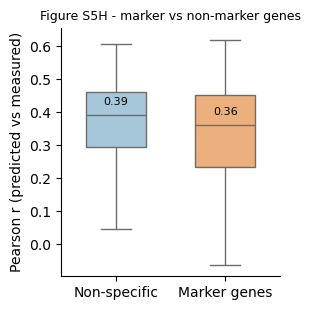

In [4]:
fig, ax = plt.subplots(figsize=(3, 3.2))
order = ["Non-specific", "Marker genes"]
sns.boxplot(data=markers, x="gene_group", y="correlation", order=order,
            hue="gene_group", legend=False, showfliers=False, width=0.55,
            palette={"Non-specific": "#9ecae1", "Marker genes": "#fdae6b"}, ax=ax)
for i, grp in enumerate(order):
    m = markers.loc[markers.gene_group == grp, "correlation"].median()
    ax.text(i, m + 0.03, f"{m:.2f}", ha="center", fontsize=8)
ax.set_xlabel("")
ax.set_ylabel("Pearson r (predicted vs measured)")
ax.set_title("Figure S5H - marker vs non-marker genes", fontsize=9)
sns.despine()
fig.tight_layout(); plt.show()

## Takeaway

Non-marker ("non-specific") genes are predicted at least as accurately as
canonical marker genes — slightly more so. Prediction accuracy is therefore
not a by-product of reproducing the strongest cell-type marker signals:
Path2Space predicts expression variation across the transcriptome, beyond
cell-type identity.